## Classification(Multi-Class): Iris Dataset

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=1
)

In [3]:
X_train[:10]

array([[6.1, 3. , 4.6, 1.4],
       [7.7, 3. , 6.1, 2.3],
       [5.6, 2.5, 3.9, 1.1],
       [6.4, 2.8, 5.6, 2.1],
       [5.8, 2.8, 5.1, 2.4],
       [5.3, 3.7, 1.5, 0.2],
       [5.5, 2.3, 4. , 1.3],
       [5.2, 3.4, 1.4, 0.2],
       [6.5, 2.8, 4.6, 1.5],
       [6.7, 2.5, 5.8, 1.8]])

In [4]:
y_train[:10]

array([1, 2, 1, 2, 2, 0, 1, 0, 1, 2])

In [6]:
for i, value in enumerate(iris.target_names):
    print(i, value)

0 setosa
1 versicolor
2 virginica


In [7]:
# NO NEED FOR SCALLING BECAUSE OUR VALUES ARE NOT FAR APART

In [8]:
len(X_train), len(y_train), len(X_test), len(y_test)

(120, 120, 30, 30)

In [9]:
# Train a Classifier. Let's use a Logistic Regression
from sklearn.linear_model import LogisticRegression
clf_model = LogisticRegression(max_iter=200)
clf_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [18]:
# Evaluate the Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
y_pred = clf_model.predict(X_test)

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9666666666666667


In [12]:
print(y_pred)
print(y_test)

[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 2 0 2 1 0 0 1 2]
[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2]


In [14]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.92      0.96        13
           2       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [15]:
# For Class A: Precision_A = TruePositives_A / (TruePositives_A + FalsePo
# For Class B: Precision_B = TruePositives_B / (TruePositives_B + FalsePo
# For Class C: Precision_C = TruePositives_C / (TruePositives_C + FalsePo
# for our problem, if we should calculate by hand:
print(6/(1+0))
print((6/7)*100)

6.0
85.71428571428571


In [16]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]


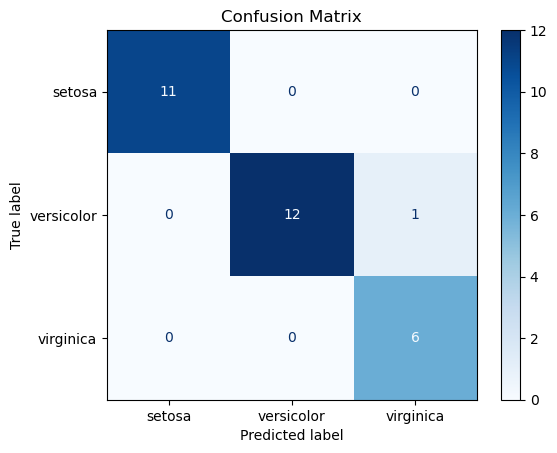

In [19]:
import matplotlib.pyplot as plt
cm_display = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels = iris.target_names)
cm_display.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
# plt.colorbar()
plt.show()

In [20]:
len(X_test)

30

In [21]:
print(y_pred)
print(y_test)

[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 2 0 2 1 0 0 1 2]
[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2]


## Creating a Prediction Function

In [23]:
def predict_flower(sepal_length, sepal_width, petal_length, petal_width):
    sample = [[sepal_length, sepal_width, petal_length, petal_width]]
# Predict
    pred = clf_model.predict(sample)[0]
    species = iris.target_names
    prediction = f'The specie of flower is {species[pred]}'
    return prediction

In [24]:
print(predict_flower(5.1, 3.5, 1.4, 0.2))

The specie of flower is setosa


In [25]:
print(predict_flower(6.0, 3.0, 4.8, 1.8))

The specie of flower is virginica


In [26]:
clf_model.predict([[5.1, 3.5, 1.4, 0.2]])

array([0])

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
    

## Data Preprocessing and Feature Engineering

In [29]:
df = pd.DataFrame({
    'name': ['Tomi', 'Funmi', 'Arafat', 'Halimat', 'Abiola'],
    'age': [25, 30, np.nan, 35, 40],
    'income': [50000, 60000, 55000, np.nan, 65000]
})
df

,name,age,income
0,Tomi,25.0,50000.0
1,Funmi,30.0,60000.0
2,Arafat,NaN,55000.0
3,Halimat,35.0,NaN
4,Abiola,40.0,65000.0


In [30]:
from sklearn.impute import SimpleImputer
# Impute with column mean, check docs for others
imputer = SimpleImputer(strategy='mean')
df['age'] = imputer.fit_transform(df['age'].to_numpy().reshape(-1,1))
# the reshape methode reshapes your array with 1 column and as many rows 
# accommodate the data. This operation will result in a 2D array with a s
# where n is the number of elements in your original array
df

,name,age,income
0,Tomi,25.0,50000.0
1,Funmi,30.0,60000.0
2,Arafat,32.5,55000.0
3,Halimat,35.0,NaN
4,Abiola,40.0,65000.0


In [ ]:
from sklearn.impute import SimpleImputer
# Impute with column mean, check docs for others
imputer = SimpleImputer(strategy='mean')
df['age'] = imputer.fit_transform(df['age'].to_numpy().reshape(-1,1))
# the reshape methode reshapes your array with 1 column and as many rows 
# accommodate the data. This operation will result in a 2D array with a s
# where n is the number of elements in your original array
df

In [31]:
df = pd.DataFrame({
    'age': [25, 30, np.nan, 35, 40],
    'income': [50000, 60000, 55000, np.nan, 65000]
})
df

,age,income
0,25.0,50000.0
1,30.0,60000.0
2,NaN,55000.0
3,35.0,NaN
4,40.0,65000.0


In [32]:
df = pd.DataFrame({
    'age': [25, 30, np.nan, 35, 40],
    'income': [50000, 60000, 55000, np.nan, 65000]
})
df

,age,income
0,25.0,50000.0
1,30.0,60000.0
2,NaN,55000.0
3,35.0,NaN
4,40.0,65000.0


In [33]:
imputer = SimpleImputer(strategy='median')
clean_df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
clean_df

,age,income
0,25.0,50000.0
1,30.0,60000.0
2,32.5,55000.0
3,35.0,57500.0
4,40.0,65000.0


In [34]:
df[['age', 'income']]

,age,income
0,25.0,50000.0
1,30.0,60000.0
2,NaN,55000.0
3,35.0,NaN
4,40.0,65000.0


## KNN IMPUTER

In [35]:
df = pd.DataFrame({
'age': [25, 30, np.nan, 35, 40, 10, 25],
'income': [50000, 60000, 55000, np.nan, 65000, 20000, 25000]
})
df

,age,income
0,25.0,50000.0
1,30.0,60000.0
2,NaN,55000.0
3,35.0,NaN
4,40.0,65000.0
5,10.0,20000.0
6,25.0,25000.0


In [36]:
from sklearn.impute import KNNImputer
# distances are calculated using a modified Euclidean distance metric (na
imputer = KNNImputer(n_neighbors=2)
clean_df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
clean_df
# for age: mean of index 0 and 1
# for income: mean of index 1 and 4

,age,income
0,25.0,50000.0
1,30.0,60000.0
2,27.5,55000.0
3,35.0,62500.0
4,40.0,65000.0
5,10.0,20000.0
6,25.0,25000.0


## Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clean_df)
X_scaled

array([[-0.2852987 ,  0.10540926],
       [ 0.2852987 ,  0.69570109],
       [ 0.        ,  0.40055517],
       [ 0.8558961 ,  0.84327404],
       [ 1.42649351,  0.990847  ],
       [-1.99709091, -1.66546623],
       [-0.2852987 , -1.37032032]])

## MinMaxScaler

In [38]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(clean_df)
X_scaled

array([[0.5       , 0.66666667],
       [0.66666667, 0.88888889],
       [0.58333333, 0.77777778],
       [0.83333333, 0.94444444],
       [1.        , 1.        ],
       [0.        , 0.        ],
       [0.5       , 0.11111111]])

MaxAbsScaler

In [39]:
clean_df

,age,income
0,25.0,50000.0
1,30.0,60000.0
2,27.5,55000.0
3,35.0,62500.0
4,40.0,65000.0
5,10.0,20000.0
6,25.0,25000.0


In [40]:
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(clean_df)
X_scaled

array([[0.625     , 0.76923077],
       [0.75      , 0.92307692],
       [0.6875    , 0.84615385],
       [0.875     , 0.96153846],
       [1.        , 1.        ],
       [0.25      , 0.30769231],
       [0.625     , 0.38461538]])

## ENCODING CATEGORICAL VARIABLES